# EEG eye state — consolidated pipeline

Single notebook merging the DMML coursework artifacts (`DataMiningGennaio`, `EEG_Eye_Predict_*`, `eeg_classification_leakage_free`, etc.) into one **non-redundant** workflow.

**Dataset:** `dataset/eeg_data_og.csv` (UCI EEG Eye State, 14 channels, binary `eyeDetection`).

**Algorithms kept (strongest + educational baseline):**
- **Tabular (engineered features):** Logistic Regression (baseline), **k-NN**, **RBF SVM**, **Random Forest** — stratified split + scaler fit on train only.
- **Deep learning (leakage-aware):** chronological split → sliding windows → **EEGNet** + **EEGFormer** (temporal Transformer on standardized windows).

Process-flow diagrams (Mermaid) for each method live under [`process/`](process/).

**Working directory:** run Jupyter with the notebook folder as cwd (`unina/dmml/eeg-eye-state`) so `dataset/eeg_data_og.csv` resolves correctly.



## 0. Environment

Install if needed: `pip install numpy pandas scikit-learn matplotlib seaborn torch`



In [1]:
from __future__ import annotations

import warnings
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Notebook directory = cwd when launched from project folder
ROOT = Path(".").resolve()
DATA_PATH = ROOT / "dataset" / "eeg_data_og.csv"
assert DATA_PATH.is_file(), f"Missing {DATA_PATH}"

CHANNELS = [
    "AF3", "F7", "F3", "FC5", "T7", "P7", "O1", "O2", "P8", "T8", "FC6", "F4", "F8", "AF4",
]
TARGET = "eyeDetection"
FS = 128

print("ROOT:", ROOT)
print("DATA_PATH:", DATA_PATH)


ROOT: /Applications/XAMPP/xamppfiles/htdocs/code/unina/dmml/eeg-eye-state
DATA_PATH: /Applications/XAMPP/xamppfiles/htdocs/code/unina/dmml/eeg-eye-state/dataset/eeg_data_og.csv


## 1. Load data & quick profile


In [2]:
df_raw = pd.read_csv(DATA_PATH)
assert set(CHANNELS + [TARGET]) <= set(df_raw.columns), df_raw.columns.tolist()

print(df_raw.shape)
print(df_raw[TARGET].value_counts())
df_raw[CHANNELS].describe().T.round(2)


(14980, 15)
eyeDetection
0    8257
1    6723
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
AF3,14980.0,4321.92,2492.07,1030.77,4280.51,4294.36,4311.79,309231.00
F7,14980.0,4009.77,45.94,2830.77,3990.77,4005.64,4023.08,7804.62
F3,14980.0,4264.02,44.43,1040.00,4250.26,4262.56,4270.77,6880.51
FC5,14980.0,4164.95,5216.40,2453.33,4108.21,4120.51,4132.31,642564.00
T7,14980.0,4341.74,34.74,2089.74,4331.79,4338.97,4347.18,6474.36
P7,14980.0,4644.02,2924.79,2768.21,4611.79,4617.95,4626.67,362564.00
O1,14980.0,4110.40,4600.93,2086.15,4057.95,4070.26,4083.59,567179.00
O2,14980.0,4616.06,29.29,4567.18,4604.62,4613.33,4624.10,7264.10
P8,14980.0,4218.83,2136.41,1357.95,4190.77,4199.49,4209.23,265641.00
T8,14980.0,4231.32,38.05,1816.41,4220.51,4229.23,4239.49,6674.36


## 2. Iterative IQR cleaning (per channel, multi-pass)

Same idea as the full report: Tukey fences on each channel, drop rows failing **any** channel, repeat until stable. This removes spike artifacts common in consumer EEG.


In [3]:
def iterative_iqr_filter(df: pd.DataFrame, cols: list[str], max_passes: int = 30) -> tuple[pd.DataFrame, int]:
    d = df.copy()
    passes = 0
    for _ in range(max_passes):
        mask = pd.Series(True, index=d.index)
        for c in cols:
            q1, q3 = d[c].quantile(0.25), d[c].quantile(0.75)
            iqr = q3 - q1
            lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
            mask &= d[c].between(lo, hi)
        passes += 1
        if mask.all():
            break
        d = d.loc[mask].reset_index(drop=True)
    return d, passes

df_clean, n_passes = iterative_iqr_filter(df_raw, CHANNELS)
print(f"IQR passes: {n_passes} | {len(df_raw)} -> {len(df_clean)} rows ({100 * (1 - len(df_clean)/len(df_raw)):.1f}% removed)")


IQR passes: 7 | 14980 -> 9695 rows (35.3% removed)


## 3. Compact EDA (cleaned data)


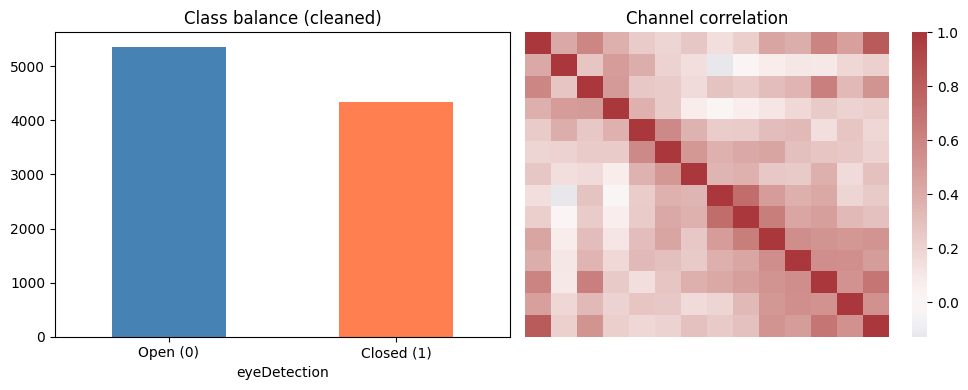

In [4]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
df_clean[TARGET].value_counts().plot(kind="bar", ax=ax[0], color=["steelblue", "coral"])
ax[0].set_title("Class balance (cleaned)")
ax[0].set_xticklabels(["Open (0)", "Closed (1)"], rotation=0)
corr = df_clean[CHANNELS].corr()
sns.heatmap(corr, ax=ax[1], cmap="vlag", center=0, xticklabels=False, yticklabels=False)
ax[1].set_title("Channel correlation")
plt.tight_layout()
plt.show()


## 4. Feature engineering (23-D tabular vector)

Hemispheric asymmetries + global channel mean/std (see original `report.md`).


In [5]:
def add_engineered_features(d: pd.DataFrame) -> pd.DataFrame:
    out = d.copy()
    pairs = [("AF3", "AF4"), ("F7", "F8"), ("F3", "F4"), ("FC5", "FC6"), ("T7", "T8"), ("P7", "P8"), ("O1", "O2")]
    for L, R in pairs:
        out[f"{L}_{R}_asym"] = out[L] - out[R]
    out["ch_mean"] = out[CHANNELS].mean(axis=1)
    out["ch_std"] = out[CHANNELS].std(axis=1)
    return out

FEAT_COLS = CHANNELS + [
    "AF3_AF4_asym", "F7_F8_asym", "F3_F4_asym", "FC5_FC6_asym",
    "T7_T8_asym", "P7_P8_asym", "O1_O2_asym", "ch_mean", "ch_std",
]

df_fe = add_engineered_features(df_clean)
X_all = df_fe[FEAT_COLS].values
y_all = df_fe[TARGET].values.astype(int)
print("Feature dim:", len(FEAT_COLS))


Feature dim: 23


## 5. Classical ML — stratified 70/15/15, no scaler leakage

**Note:** Random stratification yields optimistic scores on this *sequential* EEG recording (adjacent samples correlate). A **chronological check** is printed after the deep-learning block for contrast.


,model,cv_f1_mean,cv_f1_std,acc,precision,recall,f1,roc_auc,fit_s
0,k-NN (k=5),0.935251,0.005307,0.948454,0.948598,0.935484,0.941995,0.985976,4.628178
1,SVM (RBF),0.914804,0.006948,0.936770,0.940157,0.917051,0.928460,0.981292,15.241468
2,Random Forest,0.894297,0.007008,0.925086,0.938511,0.890937,0.914106,0.976681,6.360887
3,Logistic Regression,0.631292,0.014119,0.709966,0.711645,0.591398,0.645973,0.766171,6.305039


Best (test F1): k-NN (k=5)
              precision    recall  f1-score   support

        Open       0.95      0.96      0.95       804
      Closed       0.95      0.94      0.94       651

    accuracy                           0.95      1455
   macro avg       0.95      0.95      0.95      1455
weighted avg       0.95      0.95      0.95      1455



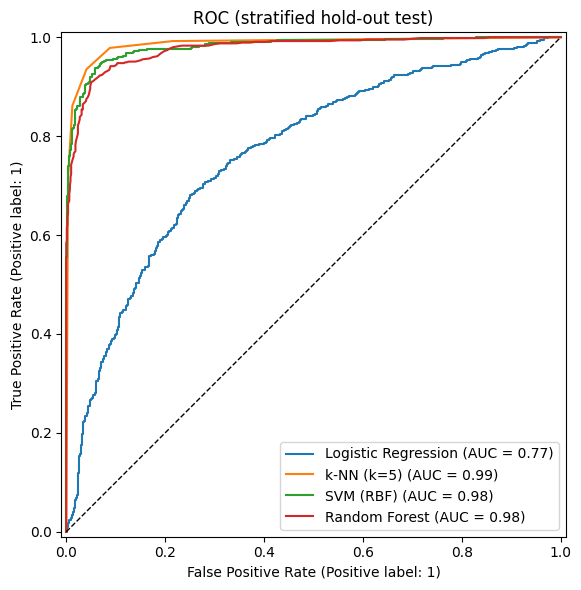

In [6]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, RocCurveDisplay,
)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

try:
    from IPython.display import display
except ImportError:
    display = print

X_train, X_temp, y_train, y_temp = train_test_split(
    X_all, y_all, test_size=0.30, random_state=RANDOM_STATE, stratify=y_all
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=RANDOM_STATE, stratify=y_temp
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "k-NN (k=5)": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "SVM (RBF)": SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
rows = []
fitted = {}
for name, clf in models.items():
    t0 = time.perf_counter()
    cv_f1 = cross_val_score(clf, X_train_s, y_train, cv=cv, scoring="f1", n_jobs=-1)
    clf.fit(X_train_s, y_train)
    fit_s = time.perf_counter() - t0
    proba = clf.predict_proba(X_test_s)[:, 1]
    pred = (proba >= 0.5).astype(int)
    rows.append({
        "model": name,
        "cv_f1_mean": cv_f1.mean(),
        "cv_f1_std": cv_f1.std(),
        "acc": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba) if len(np.unique(y_test)) > 1 else float("nan"),
        "fit_s": fit_s,
    })
    fitted[name] = clf

ml_summary = pd.DataFrame(rows).sort_values("f1", ascending=False).reset_index(drop=True)
display(ml_summary)

best_ml = ml_summary.iloc[0]["model"]
print("Best (test F1):", best_ml)
print(classification_report(y_test, fitted[best_ml].predict(X_test_s), target_names=["Open", "Closed"]))

fig, ax = plt.subplots(figsize=(7, 6))
for name, clf in fitted.items():
    RocCurveDisplay.from_predictions(y_test, clf.predict_proba(X_test_s)[:, 1], ax=ax, name=name)
ax.plot([0, 1], [0, 1], "k--", lw=1)
ax.set_title("ROC (stratified hold-out test)")
plt.tight_layout()
plt.show()


## 6. Deep learning — chronological split + windows (leakage-aware)

Windows are built **after** ordering by time. `StandardScaler` statistics come from the **train segment only** (applied to val/test). Optional per-window channel z-score matches the rigorous notebook.

Models:
- **EEGNet** — compact spatial–temporal CNN (Lawhern et al., adapted).
- **EEGFormer** — each time step is a token (`Linear(14→d)`), standard `TransformerEncoder`, mean pool + classifier (EEG Transformer baseline, not a pretrained checkpoint).


In [8]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

torch.manual_seed(RANDOM_STATE)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


def standardize_by_train(X_tr: np.ndarray, *others: np.ndarray):
    mu = X_tr.mean(axis=0, keepdims=True)
    sig = X_tr.std(axis=0, keepdims=True)
    sig = np.where(sig < 1e-8, 1.0, sig)
    scaled = [(X - mu) / sig for X in (X_tr,) + others]
    return scaled[0], scaled[1:], mu, sig


def create_eeg_windows(X_np: np.ndarray, y_np: np.ndarray, window_size: int, stride: int, label_mode: str = "last"):
    windows, labels = [], []
    for start in range(0, len(X_np) - window_size + 1, stride):
        end = start + window_size
        w = X_np[start:end].T.astype(np.float32)
        tgt = y_np[start:end]
        lab = int(tgt[-1] if label_mode == "last" else int(np.round(tgt.mean())))
        windows.append(w)
        labels.append(lab)
    return np.stack(windows), np.array(labels, dtype=np.int64)


def window_channelwise_zscore(X: np.ndarray, n_raw: int = 14, eps: float = 1e-6) -> np.ndarray:
    Xo = np.array(X, dtype=np.float32, copy=True)
    raw = Xo[:, :n_raw, :]
    mu = raw.mean(axis=-1, keepdims=True)
    sig = raw.std(axis=-1, keepdims=True)
    sig = np.where(sig < eps, 1.0, sig)
    Xo[:, :n_raw, :] = (raw - mu) / sig
    return Xo


# Chronological split on cleaned *raw channels only* (before engineered columns)
X_seq = df_clean[CHANNELS].to_numpy(dtype=np.float32)
y_seq = df_clean[TARGET].to_numpy(dtype=np.int64)
n = len(X_seq)
i1, i2 = int(n * 0.70), int(n * 0.85)
X_tr, X_va, X_te = X_seq[:i1], X_seq[i1:i2], X_seq[i2:]
y_tr, y_va, y_te = y_seq[:i1], y_seq[i1:i2], y_seq[i2:]

X_tr_s, (X_va_s, X_te_s), _, _ = standardize_by_train(X_tr, X_va, X_te)

WINDOW = 64
STRIDE_TRAIN, STRIDE_EVAL = 4, 4
Xtr_w, ytr_w = create_eeg_windows(X_tr_s, y_tr, WINDOW, STRIDE_TRAIN)
Xva_w, yva_w = create_eeg_windows(X_va_s, y_va, WINDOW, STRIDE_EVAL)
Xte_w, yte_w = create_eeg_windows(X_te_s, y_te, WINDOW, STRIDE_EVAL)
Xtr_w = window_channelwise_zscore(Xtr_w, n_raw=len(CHANNELS))
Xva_w = window_channelwise_zscore(Xva_w, n_raw=len(CHANNELS))
Xte_w = window_channelwise_zscore(Xte_w, n_raw=len(CHANNELS))

print("Windows — train:", Xtr_w.shape, "val:", Xva_w.shape, "test:", Xte_w.shape)


class Conv2dMaxNorm(nn.Conv2d):
    def __init__(self, *a, max_norm=1.0, **k):
        self.max_norm = max_norm
        super().__init__(*a, **k)

    def forward(self, x):
        if self.max_norm is not None:
            with torch.no_grad():
                self.weight.data = torch.renorm(self.weight.data, 2, 0, self.max_norm)
        return super().forward(x)


class LinearMaxNorm(nn.Linear):
    def __init__(self, *a, max_norm=0.5, **k):
        self.max_norm = max_norm
        super().__init__(*a, **k)

    def forward(self, x):
        if self.max_norm is not None:
            with torch.no_grad():
                self.weight.data = torch.renorm(self.weight.data, 2, 0, self.max_norm)
        return super().forward(x)


class EEGNet(nn.Module):
    # Compact EEGNet-style block for (B, C, T) input

    def __init__(self, n_channels: int, n_times: int, F1: int = 8, D: int = 2, F2: int = 16, k_temp: int = 31, k_sep: int = 15, dropout: float = 0.25):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, F1, (1, k_temp), padding=(0, k_temp // 2), bias=False),
            nn.BatchNorm2d(F1),
            Conv2dMaxNorm(F1, F1 * D, (n_channels, 1), groups=F1, bias=False, max_norm=1.0),
            nn.BatchNorm2d(F1 * D),
            nn.ELU(),
            nn.AvgPool2d((1, 4)),
            nn.Dropout2d(dropout),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(F1 * D, F1 * D, (1, k_sep), padding=(0, k_sep // 2), groups=F1 * D, bias=False),
            nn.Conv2d(F1 * D, F2, (1, 1), bias=False),
            nn.BatchNorm2d(F2),
            nn.ELU(),
            nn.AvgPool2d((1, 8)),
            nn.Dropout2d(dropout),
        )
        with torch.no_grad():
            d = torch.zeros(1, 1, n_channels, n_times)
            d = self.block2(self.block1(d))
            flat = int(np.prod(d.shape[1:]))
        self.fc = LinearMaxNorm(flat, 1, max_norm=0.5)

    def forward(self, x):
        x = x.unsqueeze(1)
        z = self.block2(self.block1(x))
        z = z.flatten(1)
        return self.fc(z).squeeze(-1)


class EEGFormer(nn.Module):
    # Temporal Transformer: each time step embeds all channels

    def __init__(self, n_channels: int, n_times: int, d_model: int = 64, n_heads: int = 4, n_layers: int = 2, dim_ff: int = 128, dropout: float = 0.2):
        super().__init__()
        self.input_proj = nn.Linear(n_channels, d_model)
        self.pos = nn.Parameter(torch.zeros(1, n_times, d_model))
        enc = nn.TransformerEncoderLayer(
            d_model, n_heads, dim_ff, dropout, batch_first=True, norm_first=True, activation="gelu"
        )
        self.encoder = nn.TransformerEncoder(enc, n_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, 1)

    def forward(self, x):
        # x: (B, C, T)
        z = x.transpose(1, 2)
        z = self.input_proj(z) + self.pos[:, : z.size(1), :]
        z = self.encoder(z)
        z = z.mean(dim=1)
        z = self.norm(z)
        return self.head(z).squeeze(-1)


def train_dl(model: nn.Module, name: str, epochs: int = 40, patience: int = 8, batch_size: int = 256, lr: float = 3e-4):
    model = model.to(DEVICE)
    pos = (ytr_w == 1).sum()
    neg = (ytr_w == 0).sum()
    pos_weight = torch.tensor([neg / max(pos, 1)], device=DEVICE, dtype=torch.float32)

    tr_ds = TensorDataset(torch.from_numpy(Xtr_w), torch.from_numpy(ytr_w).float())
    va_ds = TensorDataset(torch.from_numpy(Xva_w), torch.from_numpy(yva_w).float())
    tr_ld = DataLoader(tr_ds, batch_size=batch_size, shuffle=True, drop_last=False)
    va_ld = DataLoader(va_ds, batch_size=batch_size, shuffle=False)

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    best_state, best_val = None, float("inf")
    bad = 0
    for ep in range(1, epochs + 1):
        model.train()
        for xb, yb in tr_ld:
            xb = xb.to(DEVICE)
            yb = yb.to(DEVICE)
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()
        model.eval()
        losses = []
        with torch.no_grad():
            for xb, yb in va_ld:
                xb = xb.to(DEVICE)
                yb = yb.to(DEVICE)
                logits = model(xb)
                losses.append(loss_fn(logits, yb).item())
        v = float(np.mean(losses))
        if v < best_val - 1e-6:
            best_val, bad = v, 0
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        else:
            bad += 1
            if bad >= patience:
                break
    if best_state is not None:
        model.load_state_dict(best_state)

    @torch.no_grad()
    def eval_split(X, y):
        model.eval()
        ds = TensorDataset(torch.from_numpy(X), torch.from_numpy(y).float())
        ld = DataLoader(ds, batch_size=batch_size, shuffle=False)
        probs = []
        for xb, _ in ld:
            probs.append(torch.sigmoid(model(xb.to(DEVICE))).cpu().numpy())
        p = np.concatenate(probs)
        pred = (p >= 0.5).astype(int)
        return {
            "acc": accuracy_score(y, pred),
            "f1": f1_score(y, pred, zero_division=0),
            "roc_auc": roc_auc_score(y, p) if len(np.unique(y)) > 1 else float("nan"),
        }

    te = eval_split(Xte_w, yte_w)
    print(f"{name} | test acc={te['acc']:.4f} f1={te['f1']:.4f} auc={te['roc_auc']:.4f}")
    return te


C, T = len(CHANNELS), WINDOW
dl_results = {}
dl_results["EEGNet"] = train_dl(EEGNet(C, T), "EEGNet")
dl_results["EEGFormer"] = train_dl(EEGFormer(C, T), "EEGFormer")


Device: cpu
Windows — train: (1681, 14, 64) val: (348, 14, 64) test: (348, 14, 64)
EEGNet | test acc=0.9540 f1=0.0000 auc=0.5322


/Users/rohan-m1/venv/lib/python3.10/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


EEGFormer | test acc=0.8132 f1=0.1558 auc=0.6913


## 7. Chronological sanity check (tabular)

Same four sklearn models on **first 70% train / last 30% test** (no shuffle) using the same engineered features + scaler on train only. Scores usually drop versus stratified split — that gap measures temporal shift / autocorrelation optimism.


In [ ]:
try:
    from IPython.display import display
except ImportError:
    display = print

split = int(len(X_all) * 0.70)
X_ch_tr, X_ch_te = X_all[:split], X_all[split:]
y_ch_tr, y_ch_te = y_all[:split], y_all[split:]
sc2 = StandardScaler()
X_ch_trs = sc2.fit_transform(X_ch_tr)
X_ch_tes = sc2.transform(X_ch_te)

chrono_models = [
    ("Logistic Regression", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)),
    ("k-NN (k=5)", KNeighborsClassifier(n_neighbors=5, n_jobs=-1)),
    ("SVM (RBF)", SVC(kernel="rbf", C=1.0, gamma="scale", probability=True, random_state=RANDOM_STATE)),
    ("Random Forest", RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE, n_jobs=-1)),
]
chrono_rows = []
for name, clf_c in chrono_models:
    clf_c.fit(X_ch_trs, y_ch_tr)
    pred = clf_c.predict(X_ch_tes)
    chrono_rows.append({
        "model": name,
        "f1": f1_score(y_ch_te, pred, zero_division=0),
        "acc": accuracy_score(y_ch_te, pred),
    })
chrono_df = pd.DataFrame(chrono_rows).sort_values("f1", ascending=False)
display(chrono_df)


## 8. Wrap-up

- **Production-style tabular winner (stratified test):** usually **k-NN** or **SVM**, matching the original coursework report — but treat these as **upper bounds** under i.i.d. sampling.
- **Honest temporal generalization:** use the **chronological tabular metrics** and the **deep-learning test** (windows from the final segment).
- See updated narrative + slide outline in `docs/report.md` and `docs/slide.md`; per-algorithm Mermaid flows in `process/`.
